
# Lab 21: Normal Distribution


In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [ ]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore')

# 1. Normal Distributions

When we visualize the distribution of a sample, we are often interested in the mean and the standard deviation of the sample (for the rest of this lab, we will abbreviate “standard deviation” as “SD”). These two sample statistics can give us a bird’s eye view of the distribution -- by letting us know where the distribution sits on the number line and how spread out it is, respectively.

We want to check if the data is linearly related, so we should look at the data.

First, let's load in the `births` table from lecture, which is a large random sample of US births and includes information about mother-child pairs.

In [ ]:
births = Table.read_table('./DS/baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


**Question 1.1.** **Now, write a line of code to plot the distribution of mother’s ages from the `births` table.** Don’t change the last line, which will plot the mean of the sample on the distribution itself.


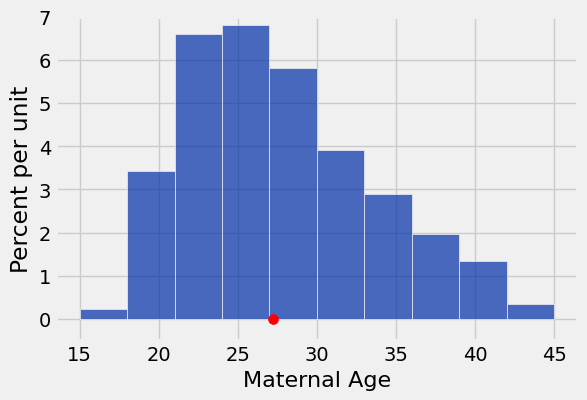

In [ ]:
births.hist('Maternal Age')

# Do not change anything below this line
plots.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50);
plots.ylim(-0.005, 0.07);

From the plot above, we can see that the mean is the center of gravity or balance point of the distribution. If you cut the distribution out of cardboard, and then placed your finger at the mean, the distribution would perfectly balance on your finger. Since the distribution above is right skewed (which means it has a long right tail), we know that the mean of the distribution is larger than the median, which is the “halfway” point of the data. Conversely, if the distribution had been left skewed, we know the mean would be smaller than the median.

**Question 1.2.** Run the following cell to compare the mean (red) and median (blue) of the distribution of mothers ages.


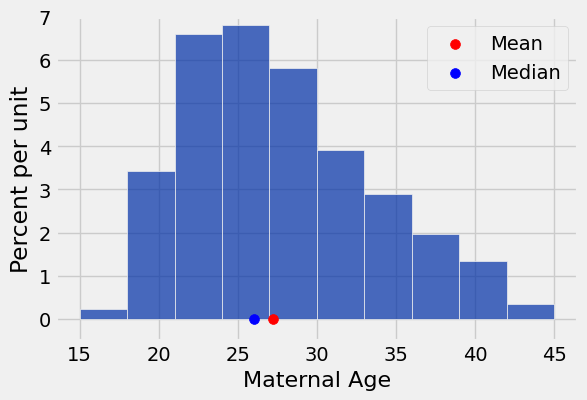

In [ ]:
births.hist("Maternal Age")
plots.scatter(np.mean(births.column("Maternal Age")), 0, color='red', zorder=2, s=50, label="Mean")
plots.scatter(np.median(births.column("Maternal Age")), 0, color='blue', zorder=2, s=50, label="Median")
plots.legend()
plots.ylim(-0.005, 0.07);

We are also interested in the standard deviation of mother’s ages. The SD gives us a sense of how variable mothers' ages are around the average mothers' age. If the SD is large, then the mothers' ages should spread over a large range from the mean. If the SD is small, then the mothers' ages should be tightly clustered around the average mother age.

**The SD of an array is defined as the "root mean square of the deviations" where the deviations are the difference between the original elements and their average.**

You can read more about Variability and SD in [Chapter 14.2](https://inferentialthinking.com/chapters/14/2/Variability.html). This chapter also goes a bit more into detail about how "root mean square of the deviations" is calculated. Fun fact! $\sigma$ (Greek letter sigma) is used to represent the SD and $\mu$ (Greek letter mu) is used for the mean.

**Question 1.3.** Assign `age_mean` to the mean of the maternal ages and `age_sd` to the SD of the maternal ages. Then run the cell below to see the width of one SD (blue) from the sample mean (red) plotted on the histogram of maternal ages.

*Hint*: `np.std` might be useful here.


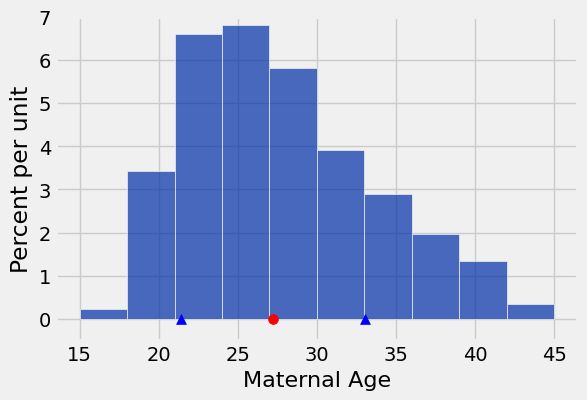

In [ ]:
age_mean = np.mean(births.column("Maternal Age"))
age_sd = np.std(births.column("Maternal Age"))
births.hist("Maternal Age")

plots.scatter(age_mean, 0, color='red', zorder=2, s=50);
plots.scatter(age_mean+age_sd, 0, marker='^', color='blue', zorder=2, s=50);
plots.scatter(age_mean-age_sd, 0, marker='^', color='blue', zorder=2, s=50);
plots.ylim(-0.005, 0.07);

In this histogram, the standard deviation is not easy to identify just by looking at the graph.

However, the distributions of some variables allow us to easily spot the standard deviation on the plot. For example, if a sample follows a **[normal distribution](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html)**, the standard deviation is easily spotted at the point of inflection (the point where the curve begins to change the direction of its curvature) of the distribution.

**Question 1.4.** Fill in the following code to examine the distribution of maternal heights, which is roughly normally distributed. We’ll plot the standard deviation on the histogram, as before - notice where one standard deviation (blue) away from the mean (red) falls on the plot.


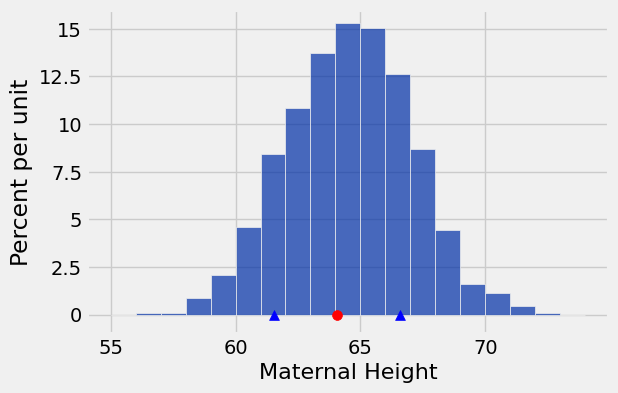

In [ ]:
height_mean = np.mean(births.column("Maternal Height")) #어머니 키 평균 계산
height_sd = np.std(births.column("Maternal Height")) # 어머니 표준편차 계산
births.hist("Maternal Height", bins=np.arange(55,75,1)) #키의 분포를 나타내는 히스토그램을 그림
# 뒤에는 막대(bin)를 55~75사이를 1단위로 나누어 그리도록 해서 세밀하게 봄

plots.scatter((height_mean), 0, color='red', zorder=2, s=50);
plots.scatter(height_mean+height_sd, 0, marker='^', color='blue', zorder=2, s=50);
plots.scatter(height_mean-height_sd, 0, marker='^', color='blue', zorder=2, s=50);
plots.ylim(-0.01, 0.16);

We don’t always know how a variable will be distributed, and making assumptions about whether or not a variable will follow a normal distribution is dangerous. However, the **Central Limit Theorem** defines one distribution that always follows a normal distribution. **The distribution of the *sums* and *means* of all large random samples drawn with replacement (and thus are independent from one another) from a single distribution (regardless of the distribution’s original shape) will be normally distributed.** Remember that the Central Limit Theorem refers to the distribution of a *statistic* calculated from a distribution, not the distribution of the original sample or population. If this is confusing, ask a staff member!


## 2. Polling and the Normal Distribution

Michelle is a statistical consultant, and she works for a group that supports Proposition 68 (which would mandate labeling of all horizontal and vertical axes, unrelated to any real California proposition) called Yes on 68.  They want to know how many Californians will vote for the proposition.

Michelle polls a random sample of all California voters, and she finds that 210 of the 400 sampled voters will vote in favor of the proposition. We have provided a table for you below which has 3 columns: the first two columns are identical to `sample`. The third column contains the proportion of total voters that chose each option.

In [ ]:
sample = Table().with_columns(
    "Vote",  make_array("Yes", "No"),
    "Count", make_array(210,   190))

sample_size = sum(sample.column("Count"))
sample_with_proportions = sample.with_column("Proportion", sample.column("Count") / sample_size)
sample_with_proportions

Vote,Count,Proportion
Yes,210,0.525
No,190,0.475


**Question 2.1.** Michelle wants to use 10,000 bootstrap resamples to compute a confidence interval for the proportion of all California voters who will vote Yes.  

Fill in the next cell to simulate an empirical distribution of Yes proportions. Use bootstrap resampling to simulate 10,000 election outcomes, and assign `resample_yes_proportions` to contain the Yes proportion of each bootstrap resample. Then, visualize `resample_yes_proportions` with a histogram. **You should see a bell shaped histogram centered near the proportion of Yes in the original sample.** **(6 points)**

*Hint:* `sample_proportions` may be useful here!


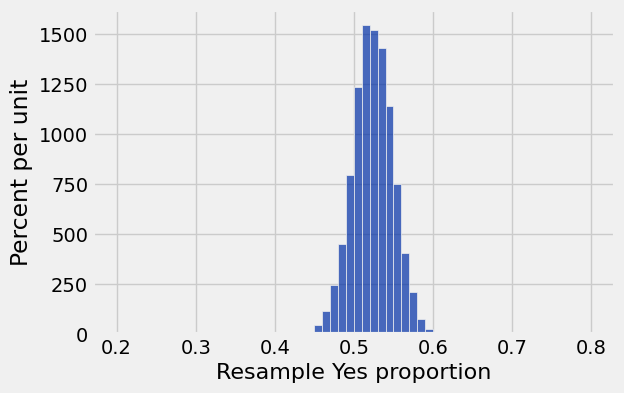

In [ ]:
resample_yes_proportions = make_array()
for i in np.arange(10000):
    resample = sample_proportions(sample_size, sample_with_proportions.column("Proportion"))
    resample_yes_proportions = np.append(resample_yes_proportions, resample.item(0))
Table().with_column("Resample Yes proportion", resample_yes_proportions).hist(bins=np.arange(.2, .8, .01))

<!-- BEGIN QUESTION -->

**Question 2.2.** Why does the Central Limit Theorem (CLT) apply in this situation, and how does it explain the distribution we see above? We recommend reviewing [14.4](https://inferentialthinking.com/chapters/14/4/Central_Limit_Theorem.html) for a refresher on CLT. **(6 points)**


The Central Limit Theorem (CLT) applies here because we are observing the distribution of a statistic (the sample proportion), not the distribution of individual votes. Since our sample size (n=400) is large and our bootstrap samples are drawn randomly, the CLT predicts that the distribution of these sample proportions will be approximately normal (bell-shaped), which is what the histogram shows.

<!-- END QUESTION -->

In a population whose members are 0 and 1, there is a simple formula for the **standard deviation of that population**:

$$\text{standard deviation of population} = \sqrt{(\text{proportion of 0s}) \times (\text{proportion of 1s})}$$

(Figuring out this formula, starting from the definition of the standard deviation, is an fun exercise for those who enjoy algebra.)

**Question 2.3.** Using only the Central Limit Theorem and the numbers of Yes and No voters in our sample of 400, *algebraically* compute the predicted standard deviation of the `resample_yes_proportions` array. Assign this number to `approximate_sd`. **Do not access the data in `resample_yes_proportions` in any way.** **(6 points)**

Remember that the standard deviation of the sample means can be computed from the population SD and the size of the sample (the formula above might be helpful). If we do not know the population SD, we can use the sample SD as a reasonable approximation in its place. [This section](https://inferentialthinking.com/chapters/14/5/Variability_of_the_Sample_Mean.html#the-sd-of-all-the-sample-means) of the textbook also may be helpful.


In [ ]:
approx_pop_sd = np.sqrt(sample_with_proportions.column("Proportion").item(0) * sample_with_proportions.column("Proportion").item(1))
approximate_sd = approx_pop_sd / np.sqrt(sample_size)
approximate_sd

0.024968730444297725

**Question 2.4.** Compute the standard deviation of the array `resample_yes_proportions`, which will act as an approximation to the true SD of the possible sample proportions. This will help verify whether your answer to question 2.3 is approximately correct. **(6 points)**


In [ ]:
exact_sd = np.std(resample_yes_proportions)
exact_sd

0.024876463595133458

**Question 2.5.** **Again, without accessing `resample_yes_proportions` in any way**, compute an approximate 95% confidence interval for the proportion of Yes voters in California. **(6 points)**

The cell below draws your interval as a red bar below the histogram of `resample_yes_proportions`; use that to verify that your answer looks right.

*Hint:* How many SDs corresponds to 95% of the distribution promised by the CLT? Recall the discussion in the textbook [here](https://inferentialthinking.com/chapters/14/3/SD_and_the_Normal_Curve.html).

*Hint:* The `approximate_sd` variable you previously defined may be helpful!


In [ ]:
yes_sample = sample_with_proportions.column("Proportion").item(0)
lower_limit = yes_sample - 2 * approximate_sd
upper_limit = yes_sample + 2 * approximate_sd
print('lower:', lower_limit, 'upper:', upper_limit)

lower: 0.475062539111 upper: 0.574937460889


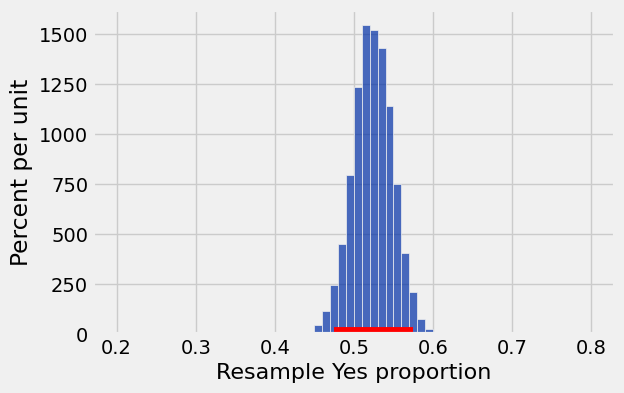

In [ ]:
# Run this cell to plot your confidence interval.
Table().with_column("Resample Yes proportion", resample_yes_proportions).hist(bins=np.arange(.2, .8, .01))
plots.plot(make_array(lower_limit, upper_limit), make_array(0, 0), c='r', lw=10);

Your confidence interval should overlap the number 0.5.  That means we can't be very sure whether Proposition 68 is winning, even though the sample Yes proportion is a bit above 0.5.

The Yes on 68 campaign really needs to know whether they're winning.  It's impossible to be absolutely sure without polling the whole population, but they'd be okay if the standard deviation of the sample mean were only 0.005.  They ask Michelle to run a new poll with a sample size that's large enough to achieve that.  (Polling is expensive, so the sample also shouldn't be bigger than necessary.)

Michelle consults Chapter 14 of the textbook.  Instead of making the conservative assumption that the population standard deviation is 0.5 (coding Yes voters as 1 and No voters as 0), she decides to assume that it's equal to the standard deviation of the sample,

$$\sqrt{(\text{Yes proportion in the sample}) \times (\text{No proportion in the sample})}.$$

**Under that assumption, Michelle decides that a sample of 9,975 would suffice.**

Does Michelle's sample size achieve the desired standard deviation of sample means? What SD would you achieve with a smaller sample size? A higher sample size?

**Question 2.6.** To explore this, first compute the SD of sample means obtained by using Michelle's sample size and assign it to `michelle_sample_mean_sd`. **(6 points)**


In [ ]:
estimated_population_sd = np.sqrt(sample_with_proportions.column("Proportion").item(0) * sample_with_proportions.column("Proportion").item(1))
michelle_sample_size = 9975
michelle_sample_mean_sd = estimated_population_sd / np.sqrt(michelle_sample_size)
print("With Michelle's sample size, you would predict a sample mean SD of %f." % michelle_sample_mean_sd)

With Michelle's sample size, you would predict a sample mean SD of 0.005000.


**Question 2.7.** Next, compute the SD of sample means that you would get from a smaller sample size. Ideally, you should pick a number that is significantly smaller, but any sample size smaller than Michelle's will do. **(5 points)**


In [ ]:
smaller_sample_size = 1000 # Michelle's sample size is 9975, so 1000 is significantly smaller
smaller_sample_mean_sd = estimated_population_sd / np.sqrt(smaller_sample_size)
print("With this smaller sample size, you would predict a sample mean SD of %f" % smaller_sample_mean_sd)

With this smaller sample size, you would predict a sample mean SD of 0.015792


**Question 2.8.** Finally, compute the SD of sample means that you would get from a larger sample size. Here, a number that is significantly larger would make any difference more obvious, but any sample size larger than Michelle's will do. **(5 points)**



In [ ]:
larger_sample_size = 50000
larger_sample_mean_sd = estimated_population_sd / np.sqrt(larger_sample_size)
print("With this larger sample size, you would predict a sample mean SD of %f" % larger_sample_mean_sd)

With this larger sample size, you would predict a sample mean SD of 0.002233


**Question 2.9.** Based off of this, was Michelle's sample size approximately the minimum sufficient sample, given her assumption that the sample SD is the same as the population SD? Assign `min_sufficient` to `True` if 9,975 was indeed approximately the minimum sufficient sample, and `False` if it wasn't. **(4 points)**


In [ ]:
min_sufficient = True
min_sufficient

True

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [45]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab21(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab21(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab21(SSU)_files/
[NbConvertApp] Making directory ./lab21(SSU)_files
[NbConvertApp] Writing 86128 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 198246 bytes to DS/lab21(SSU).pdf
